In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
var_df = (
    nav.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_df.columns = [
    "amfi_code",
    "VaR_95"
]

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [8]:
cvar_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    var95 = temp["daily_return"].quantile(0.05)

    cvar = temp[
        temp["daily_return"] <= var95
    ]["daily_return"].mean()

    cvar_list.append(
        [fund, cvar]
    )

cvar_df = pd.DataFrame(
    cvar_list,
    columns=["amfi_code", "CVaR"]
)

cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [9]:
risk_report = pd.merge(
    var_df,
    cvar_df,
    on="amfi_code"
)

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report Saved")

Report Saved


In [11]:
risk_report.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


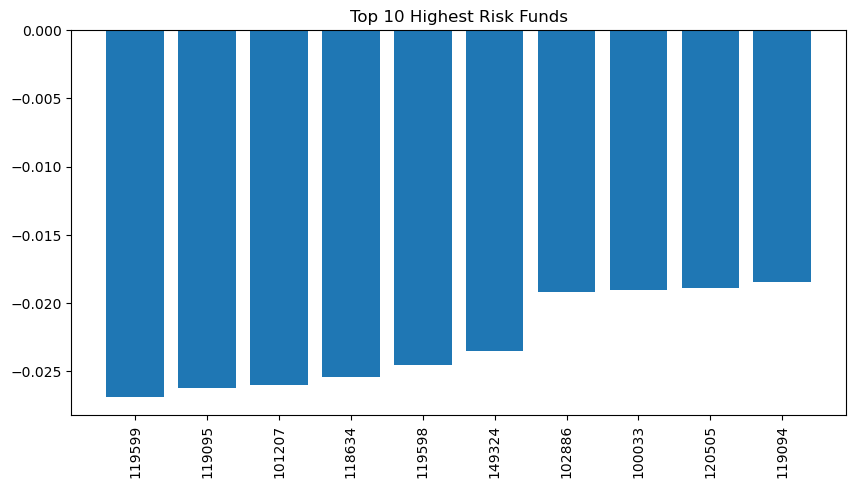

In [12]:
top10 = risk_report.sort_values(
    "VaR_95"
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["VaR_95"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Highest Risk Funds")

plt.show()

In [13]:
rolling_sharpe = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"].rolling(90).mean()
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    temp = temp.dropna()

    rolling_sharpe.append(temp)

rolling_sharpe_df = pd.concat(rolling_sharpe)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5840,100016,2022-05-09,516.5793,0.003683,-0.064787
5841,100016,2022-05-10,511.4204,-0.009987,-0.058880
5842,100016,2022-05-11,504.9889,-0.012576,-0.532521
5843,100016,2022-05-12,495.8735,-0.018051,-0.649005
5844,100016,2022-05-13,499.2941,0.006898,-0.498278


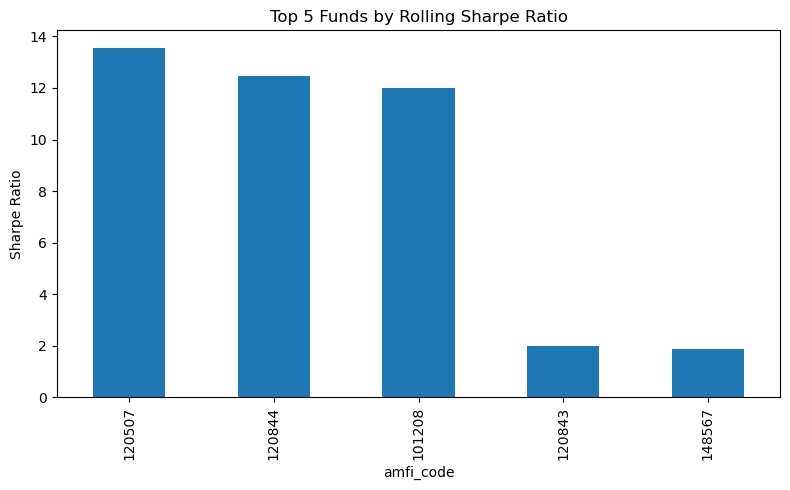

In [14]:
top5 = (
    rolling_sharpe_df.groupby("amfi_code")["rolling_sharpe"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))

top5.plot(kind="bar")

plt.title("Top 5 Funds by Rolling Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.show()

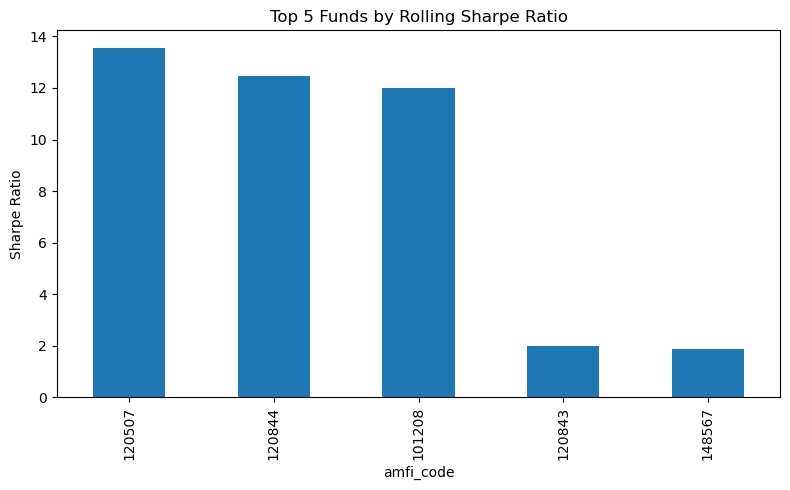

In [15]:
plt.figure(figsize=(8,5))

top5.plot(kind="bar")

plt.title("Top 5 Funds by Rolling Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [16]:
investor = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [18]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

cohort = (
    investor.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

cohort.columns = [
    "investor_id",
    "cohort_year"
]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [19]:
investor = investor.merge(
    cohort,
    on="investor_id"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [20]:
cohort_summary = (
    investor.groupby("cohort_year")
    .agg(
        total_invested=("amount_inr","sum"),
        avg_investment=("amount_inr","mean"),
        investors=("investor_id","nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,total_invested,avg_investment,investors
0,2024,3491125187,107422.541832,4803
1,2025,30455243,109158.577061,197


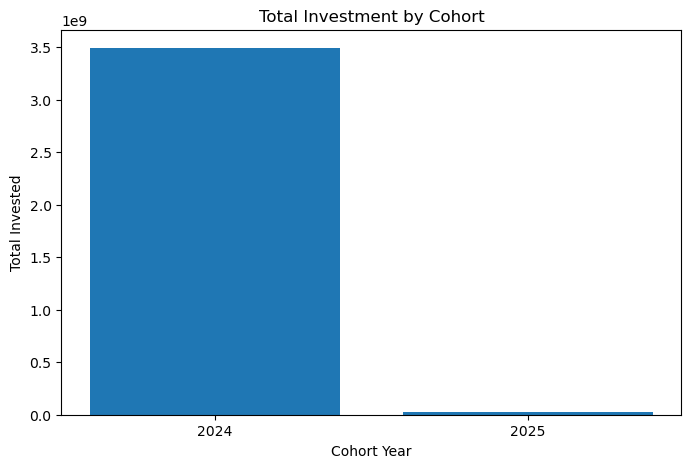

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_summary["cohort_year"].astype(str),
    cohort_summary["total_invested"]
)

plt.title("Total Investment by Cohort")

plt.xlabel("Cohort Year")

plt.ylabel("Total Invested")

plt.show()

In [22]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Cohort Report Saved")

Cohort Report Saved


In [23]:
investor = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [24]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

investor = investor.sort_values(
    ["investor_id", "transaction_date"]
)

In [25]:
investor["gap_days"] = (
    investor.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0


In [26]:
txn_count = (
    investor.groupby("investor_id")
    .size()
    .reset_index(name="txn_count")
)

active_investors = txn_count[
    txn_count["txn_count"] >= 6
]

active_investors.head()

,investor_id,txn_count
1,INV000002,6
3,INV000004,9
4,INV000005,8
5,INV000006,6
7,INV000008,8


In [27]:
sip_continuity = (
    investor.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index()
)

sip_continuity.columns = [
    "investor_id",
    "avg_gap_days"
]

sip_continuity.head()

,investor_id,avg_gap_days
0,INV000001,38.000
1,INV000002,82.800
2,INV000003,238.000
3,INV000004,53.375
4,INV000005,52.000


In [28]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [29]:
sip_continuity["status"].value_counts()

status
At Risk    4305
Healthy     695
Name: count, dtype: int64

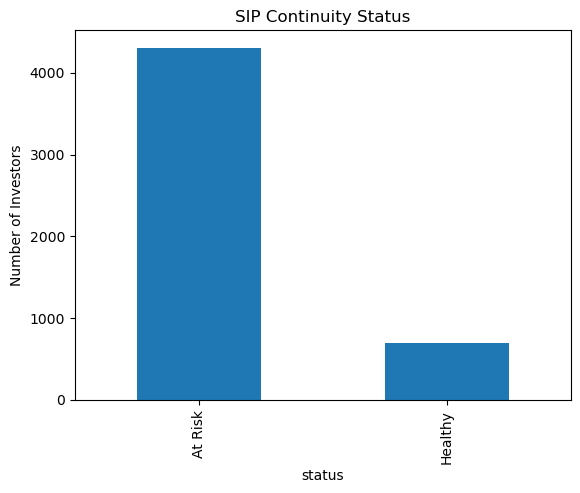

In [30]:
sip_continuity["status"].value_counts().plot(
    kind="bar"
)

plt.title("SIP Continuity Status")
plt.ylabel("Number of Investors")
plt.show()

In [31]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved")

SIP Continuity Report Saved


In [32]:
performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [33]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [34]:
def recommend_funds(risk_level):

    if risk_level == "Low":
        risk_grade = "Low"

    elif risk_level == "Moderate":
        risk_grade = "Moderate"

    else:
        risk_grade = "High"

    result = (
        performance[
            performance["risk_grade"] == risk_grade
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return result[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

In [35]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08
38,DSP Midcap Fund - Regular - Growth,High,0.90,17.16


In [36]:
recommendation = recommend_funds("High")

recommendation.to_csv(
    "../reports/recommendation.csv",
    index=False
)

print("Recommendation Saved")

Recommendation Saved


In [37]:
print("""
1. Highest risk funds identified using VaR and CVaR analysis.
2. Rolling Sharpe Ratio highlights top risk-adjusted performers.
3. Recent investor cohorts contributed the highest investment volume.
4. SIP continuity analysis identified at-risk investors with gaps >35 days.
5. Fund recommendations generated using Sharpe Ratio and Risk Grade.
""")


1. Highest risk funds identified using VaR and CVaR analysis.
2. Rolling Sharpe Ratio highlights top risk-adjusted performers.
3. Recent investor cohorts contributed the highest investment volume.
4. SIP continuity analysis identified at-risk investors with gaps >35 days.
5. Fund recommendations generated using Sharpe Ratio and Risk Grade.

